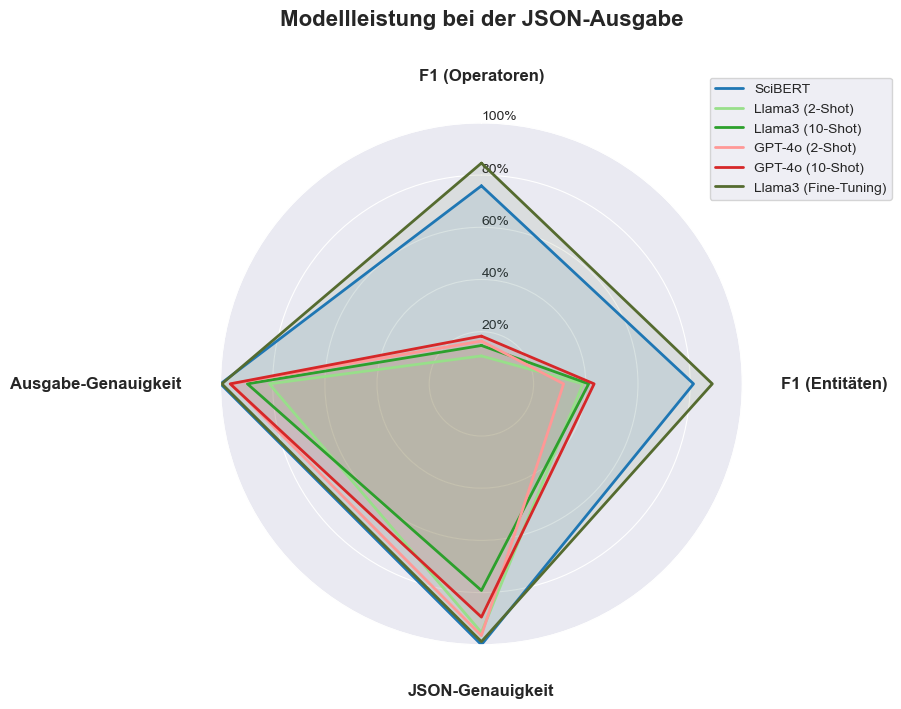

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Datenvorbereitung
models = ['SciBERT', 'Llama3 (2-Shot)', 'Llama3 (10-Shot)', 'GPT-4o (2-Shot)', 'GPT-4o (10-Shot)', 'Llama3 (Fine-Tuning)']
f1_operators = [75.9, 10.7, 14.7, 16.4, 18.3, 84.6]
f1_entities = [81.3, 38.9, 41.1, 31.5, 43.2, 88.5]
json_error = [0, 4.7, 20.8, 3.5, 10.6, 1.2]  # SciBERT JSON-Fehler auf 0 gesetzt
output_error = [0, 18.7, 10.3, 4.0, 3.7, 0.5]  # SciBERT Ausgabefehler auf 0 gesetzt

# Genauigkeiten berechnen
json_accuracy = [100 - x for x in json_error]
output_accuracy = [100 - x for x in output_error]

# Kategorien für das Sterndiagramm
categories = ['F1 (Operatoren)', 'F1 (Entitäten)', 'JSON-Genauigkeit', 'Ausgabe-Genauigkeit']
N = len(categories)

# Winkel für die Achsen berechnen
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Kreis vervollständigen

# Daten für jedes Modell vorbereiten
model_data = []
for i in range(len(models)):
    values = [f1_operators[i], f1_entities[i], json_accuracy[i], output_accuracy[i]]
    values += values[:1]
    model_data.append(values)

# Plot einrichten
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Angepasste Farbauswahl für die Modelle
colors = ['#1f77b4', '#98df8a', '#2ca02c',
          '#ff9896', '#d62728', '#556B2F']

# Jedes Modell plotten
for i, (values, color) in enumerate(zip(model_data, colors)):
    ax.plot(angles, values, label=models[i], color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.1)

# Plot anpassen
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Radiale Gitterlinien und Labels anpassen
ax.set_rgrids([20, 40, 60, 80, 100], labels=['20%', '40%', '60%', '80%', '100%'], angle=0, fontsize=10)
ax.set_ylim(0, 100)

# Theta-Achsenbeschriftungen entfernen
ax.set_thetagrids([])

# Manuelle Positionierung der Kategorienamen
for angle, label in zip(angles[:-1], categories):
    angle_rad = angle
    x = angle_rad
    y = 115  # Position der Labels noch weiter nach außen
    if angle_rad == 0:
        ha, va = 'center', 'bottom'
    elif 0 < angle_rad < np.pi:
        ha, va = 'left', 'center'
    elif angle_rad == np.pi:
        ha, va = 'center', 'top'
    else:
        ha, va = 'right', 'center'
    ax.text(x, y, label, ha=ha, va=va, fontsize=12, fontweight='bold')

# Legende hinzufügen
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

# Titel hinzufügen
plt.title("Modellleistung bei der JSON Ausgabe", fontsize=16, fontweight='bold', pad=70)

# Layout optimieren und Plot speichern
plt.tight_layout()
plt.savefig('star_plot.png', bbox_inches='tight')
plt.show()

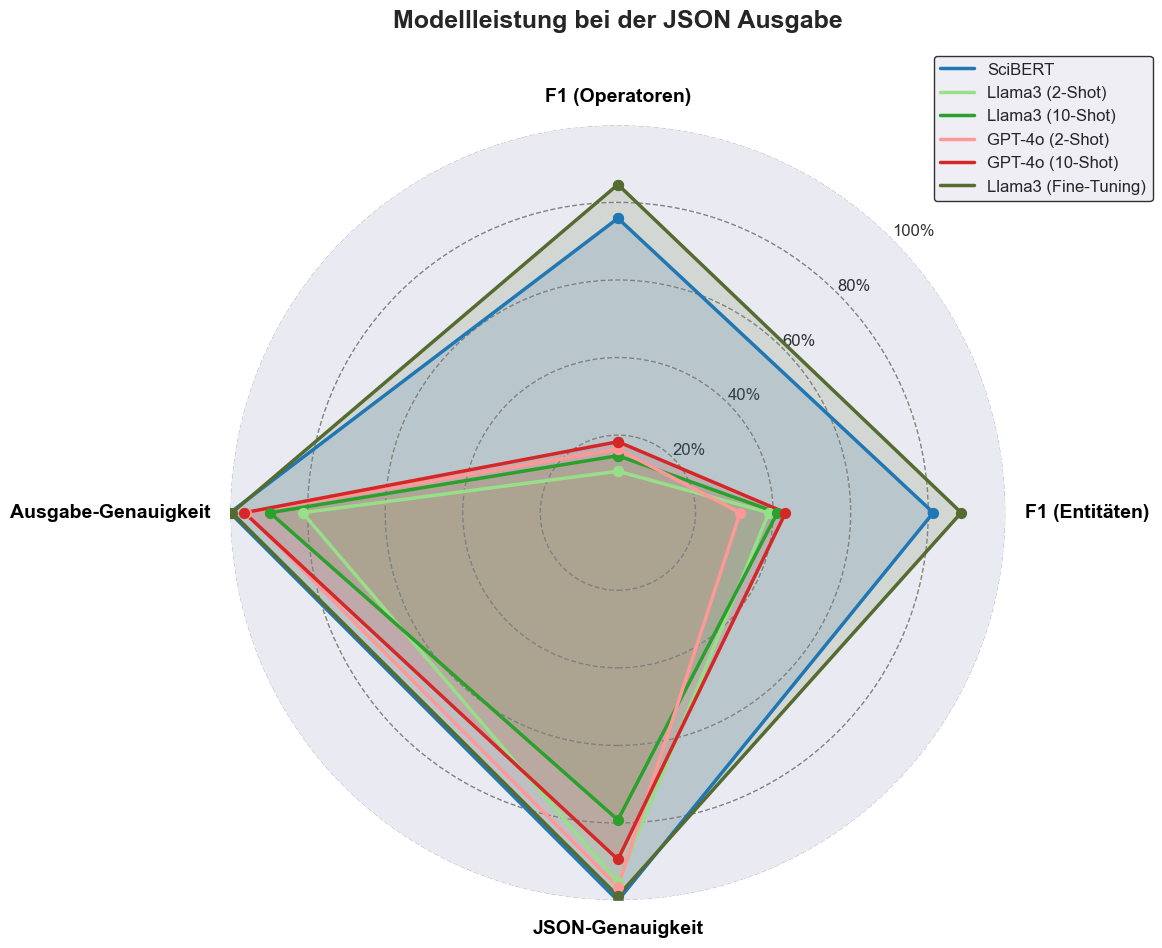

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Datenvorbereitung
models = ['SciBERT', 'Llama3 (2-Shot)', 'Llama3 (10-Shot)', 'GPT-4o (2-Shot)', 'GPT-4o (10-Shot)', 'Llama3 (Fine-Tuning)']
f1_operators = [75.9, 10.7, 14.7, 16.4, 18.3, 84.6]
f1_entities = [81.3, 38.9, 41.1, 31.5, 43.2, 88.5]
json_error = [0, 4.7, 20.8, 3.5, 10.6, 1.2]  # SciBERT JSON-Fehler auf 0 gesetzt
output_error = [0, 18.7, 10.3, 4.0, 3.7, 0.5]  # SciBERT Ausgabefehler auf 0 gesetzt

# Genauigkeiten berechnen
json_accuracy = [100 - x for x in json_error]
output_accuracy = [100 - x for x in output_error]

# Kategorien für das Sterndiagramm
categories = ['F1 (Operatoren)', 'F1 (Entitäten)', 'JSON-Genauigkeit', 'Ausgabe-Genauigkeit']
N = len(categories)

# Winkel für die Achsen berechnen
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Kreis vervollständigen

# Daten für jedes Modell vorbereiten
model_data = []
for i in range(len(models)):
    values = [f1_operators[i], f1_entities[i], json_accuracy[i], output_accuracy[i]]
    values += values[:1]
    model_data.append(values)

# Plot einrichten
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

# Angepasste Farbauswahl für die Modelle
colors = ['#1f77b4', '#98df8a', '#2ca02c', '#ff9896', '#d62728', '#556B2F']

# Jedes Modell plotten
for i, (values, color) in enumerate(zip(model_data, colors)):
    ax.plot(angles, values, label=models[i], color=color, linewidth=2.5)
    ax.fill(angles, values, color=color, alpha=0.15)

    # Kleine Kreise an den Ecken hinzufügen
    ax.scatter(angles, values, color=color, s=50, zorder=10)

# Plot anpassen
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Radiale Gitterlinien und Labels anpassen
ax.set_rgrids([20, 40, 60, 80, 100], labels=['20%', '40%', '60%', '80%', '100%'], angle=45, fontsize=12, color='black', alpha=0.8)
ax.set_ylim(0, 100)

# Nullpunkt besser sichtbar machen
ax.plot(angles, [0] * len(angles), color='black', linewidth=2, linestyle='-')

# Kreis besser sichtbar machen
for radius in [20, 40, 60, 80, 100]:
    circle = plt.Circle((0, 0), radius, transform=ax.transData._b, fill=False, color='gray', linestyle='--', linewidth=1)
    ax.add_artist(circle)

# Theta-Achsenbeschriftungen entfernen
ax.set_thetagrids([])

# Manuelle Positionierung der Kategorienamen
for angle, label in zip(angles[:-1], categories):
    angle_rad = angle
    x = angle_rad
    y = 105  # Position der Labels außerhalb des Diagramms für bessere Lesbarkeit
    if angle_rad == 0:
        ha, va = 'center', 'bottom'
    elif 0 < angle_rad < np.pi:
        ha, va = 'left', 'center'
    elif angle_rad == np.pi:
        ha, va = 'center', 'top'
    else:
        ha, va = 'right', 'center'
    ax.text(x, y, label, ha=ha, va=va, fontsize=14, fontweight='bold', color='black')

# Legende hinzufügen
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=12, frameon=True, edgecolor='black')

# Titel hinzufügen
plt.title("Modellleistung bei der JSON Ausgabe", fontsize=18, fontweight='bold', pad=70)

# Layout optimieren und Plot speichern
plt.tight_layout()
plt.savefig('star_plot.svg', format='svg', bbox_inches='tight', dpi=300)
plt.show()

In [5]:
import plotly.graph_objects as go
import numpy as np
import plotly.offline as pyo

# Datenvorbereitung
models = ['SciBERT', 'Llama3 (2-Shot)', 'Llama3 (10-Shot)', 'GPT-4o (2-Shot)', 'GPT-4o (10-Shot)', 'Llama3 (Fine-Tuning)']
f1_operators = [75.9, 10.7, 14.7, 16.4, 18.3, 84.6]
f1_entities = [81.3, 38.9, 41.1, 31.5, 43.2, 88.5]
json_error = [0, 4.7, 20.8, 3.5, 10.6, 1.2]  # SciBERT JSON-Fehler auf 0 gesetzt
output_error = [0, 18.7, 10.3, 4.0, 3.7, 0.5]  # SciBERT Ausgabefehler auf 0 gesetzt

# Genauigkeiten berechnen
json_accuracy = [100 - x for x in json_error]
output_accuracy = [100 - x for x in output_error]

# Kategorien für das Sterndiagramm
categories = ['F1 (Operatoren)', 'F1 (Entitäten)', 'JSON-Genauigkeit', 'Ausgabe-Genauigkeit']

# Daten für jedes Modell vorbereiten
model_data = []
for i in range(len(models)):
    values = [f1_operators[i], f1_entities[i], json_accuracy[i], output_accuracy[i]]
    values += values[:1]  # Kreis vervollständigen
    model_data.append(values)

# Plot einrichten
fig = go.Figure()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
patterns = ['/', '\\', '|', '-', '+', 'x']  # Muster zur besseren Unterscheidung

# Jedes Modell plotten
for i, (values, model, color, pattern) in enumerate(zip(model_data, models, colors, patterns)):
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories + [categories[0]],
        fill='toself',
        name=model,
        line=dict(color=color, dash='dash'),
        fillcolor=color,  # Hinzufügen eines Musters für bessere Unterscheidbarkeit
        opacity=0.7  # Transparenz für Überlappungen
    ))

# Layout anpassen
fig.update_layout(
    title=go.layout.Title(text='Modellleistung bei der JSON-Ausgabe', font=dict(size=18, weight='bold')),
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 100], showline=True, linewidth=1, gridcolor='black', gridwidth=0.5)
    ),
    showlegend=True,
    height=700,
    width=900,
    template='plotly_white'
)

# Plot anzeigen
pyo.plot(fig, filename='model_performance_plot.html')

'model_performance_plot.html'

In [9]:
import plotly.graph_objects as go
import plotly.offline as pyo

# Data preparation
models = ['SciBERT', 'Llama3 (2-Shot)', 'Llama3 (10-Shot)', 'GPT-4o (2-Shot)', 'GPT-4o (10-Shot)', 'Llama3 (Fine-Tuning)']
f1_operators = [75.9, 10.7, 14.7, 16.4, 18.3, 84.6]
f1_entities = [81.3, 38.9, 41.1, 31.5, 43.2, 88.5]
json_accuracy = [100, 95.3, 79.2, 96.5, 89.4, 98.8]  # 100 - json_error
output_accuracy = [100, 81.3, 89.7, 96.0, 96.3, 99.5]  # 100 - output_error

# Categories for the star plot
categories = ['F1 (Operatoren)', 'F1 (Entitäten)', 'JSON-Genauigkeit', 'Ausgabe-Genauigkeit']

# Prepare data for each model
model_data = []
for i in range(len(models)):
    values = [f1_operators[i], f1_entities[i], json_accuracy[i], output_accuracy[i]]
    values += values[:1]  # Complete the circle
    model_data.append(values)

# Set up the plot
fig = go.Figure(
    data=[
        go.Scatterpolar(r=model_data[i], theta=categories + [categories[0]], fill='toself', name=models[i], line=dict(color=color))
        for i, color in enumerate(['#1f77b4', '#98df8a', '#2ca02c', '#ff9896', '#d62728', '#556B2F'])
    ],
    layout=go.Layout(
        title=go.layout.Title(text='Modellleistung bei der JSON-Ausgabe'),
        polar=dict(radialaxis=dict(visible=True, range=[0, 100], showline=True, linewidth=1, gridcolor='black', gridwidth=0.5)),
        showlegend=True
    )
)

# Display the plot
pyo.plot(fig)

'temp-plot.html'

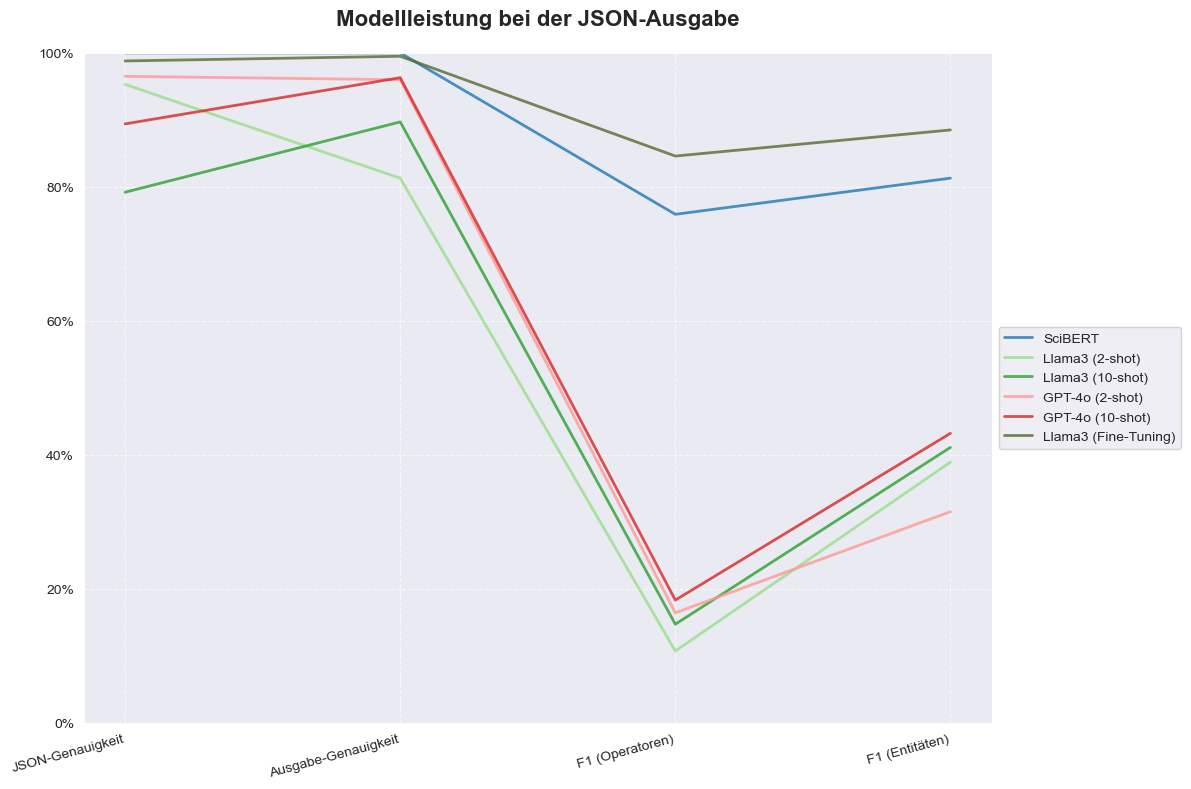

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Datenvorbereitung
models = ['SciBERT', 'Llama3 (2-shot)', 'Llama3 (10-shot)', 'GPT-4o (2-shot)', 'GPT-4o (10-shot)', 'Llama3 (Fine-Tuning)']
f1_operators = [75.9, 10.7, 14.7, 16.4, 18.3, 84.6]
f1_entities = [81.3, 38.9, 41.1, 31.5, 43.2, 88.5]
json_error = [0, 4.7, 20.8, 3.5, 10.6, 1.2]
output_error = [0, 18.7, 10.3, 4.0, 3.7, 0.5]

# Genauigkeiten berechnen
json_accuracy = [100 - x for x in json_error]
output_accuracy = [100 - x for x in output_error]

# DataFrame erstellen mit neuer Reihenfolge der Spalten
df = pd.DataFrame({
    'Model': models,
    'JSON-Genauigkeit': json_accuracy,
    'Ausgabe-Genauigkeit': output_accuracy,
    'F1 (Operatoren)': f1_operators,
    'F1 (Entitäten)': f1_entities
})

# Farbauswahl für die Modelle
colors = ['#1f77b4', '#98df8a', '#2ca02c',
          '#ff9896', '#d62728', '#556B2F']

# Plot einrichten
fig, ax = plt.subplots(figsize=(12, 8))

# Dimensionale Anker plotten
for i, model in enumerate(models):
    ax.plot(df.columns[1:], df.loc[i, df.columns[1:]], color=colors[i], label=model, linewidth=2, alpha=0.8)

# Y-Achse anpassen
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 20))
ax.set_yticklabels([f'{x}%' for x in range(0, 101, 20)])

# X-Achse anpassen
ax.set_xticks(range(len(df.columns[1:])))
ax.set_xticklabels(df.columns[1:], rotation=15, ha='right')

# Gitterlinien hinzufügen
ax.grid(True, linestyle='--', alpha=0.7)

# Legende hinzufügen
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Titel hinzufügen
plt.title("Modellleistung bei der JSON-Ausgabe", fontsize=16, fontweight='bold', pad=20)

# Layout optimieren und Plot speichern
plt.tight_layout()
plt.savefig('dimensional_anchors_plot.png', bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Datenvorbereitung
models = ['SciBERT', 'Llama3 (2-Shot)', 'Llama3 (10-Shot)',
          'GPT-4o (2-Shot)', 'GPT-4o (10-Shot)', 'Llama3 (Fine-Tuning)']
f1_operators = [75.9, 10.7, 14.7, 16.4, 18.3, 84.6]
f1_entities = [81.3, 38.9, 41.1, 31.5, 43.2, 88.5]
json_error = [0, 4.7, 20.8, 3.5, 10.6, 1.2]
output_error = [0, 18.7, 10.3, 4.0, 3.7, 0.5]

# Genauigkeiten berechnen
json_accuracy = [100 - x for x in json_error]
output_accuracy = [100 - x for x in output_error]

# DataFrame erstellen mit neuer Reihenfolge der Spalten
df = pd.DataFrame({
    'Model': models,
    'JSON-Genauigkeit': json_accuracy,
    'Ausgabe-Genauigkeit': output_accuracy,
    'F1 (Operatoren)': f1_operators,
    'F1 (Entitäten)': f1_entities
})

# Farbauswahl für die Modelle (benutzerdefiniert)
colors = ['#1f77b4', '#98df8a', '#2ca02c',
          '#ff9896', '#d62728', '#556B2F']

# Plot einrichten
fig, ax = plt.subplots(figsize=(12, 8))

# Marker definieren
markers = ['o', 's', 'D', '^', 'v', 'P']

# Dimensionale Anker plotten
for i, model in enumerate(models):
    ax.plot(df.columns[1:], df.loc[i, df.columns[1:]],
            color=colors[i], label=model,
            linewidth=2, alpha=0.8, marker=markers[i])

# Y-Achse anpassen
ax.set_ylim(0, 102)  # Obergrenze leicht über 100 % gesetzt
ax.set_ylabel('Wert (%)', fontsize=14)
ax.set_yticks(range(0, 101, 20))
ax.set_yticklabels([f'{x}%' for x in range(0, 101, 20)], fontsize=12)

# X-Achse anpassen
ax.set_xticks(range(len(df.columns[1:])))
ax.set_xticklabels(df.columns[1:], rotation=15, ha='right', fontsize=12)
ax.set_xlabel('Metriken', fontsize=14)

# Gitterlinien hinzufügen
ax.grid(True, linestyle='--', alpha=0.7)

# Legende hinzufügen
ax.legend(loc='best', ncol=2, fontsize=10)

# Titel hinzufügen
plt.title("Modellleistung bei der JSON-Ausgabe", fontsize=16, fontweight='bold', pad=20)

# Layout optimieren und Plot speichern
plt.tight_layout()
plt.savefig('dimensional_anchors_plot2.png', bbox_inches='tight')
plt.show()
